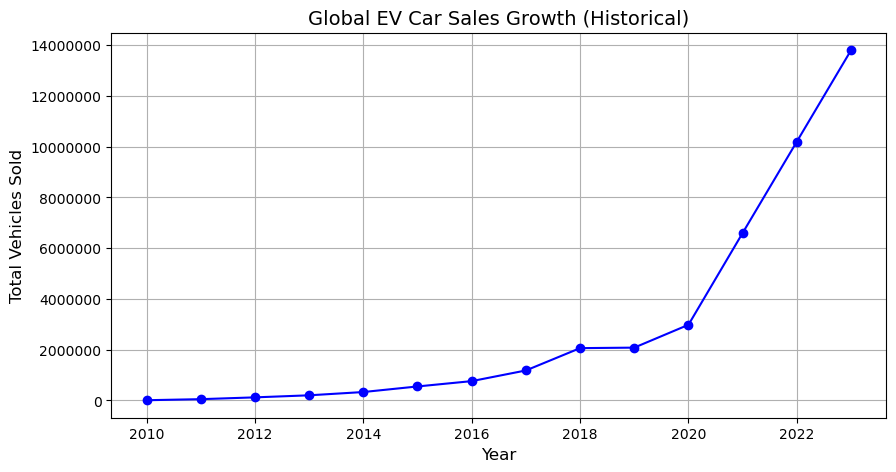

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('IEA Global EV Data 2024.csv')

# 2. THE FIX: Clean the column names by removing any hidden spaces!
df.columns = df.columns.str.strip()

# 3. Apply the corrected filter
global_sales = df[
    (df['region'] == 'World') & 
    (df['category'] == 'Historical') & 
    (df['parameter'] == 'EV sales') & 
    (df['mode'] == 'Cars') & 
    (df['powertrain'].isin(['BEV', 'PHEV']))
]

# 4. Group and sum up the sales per year
yearly_totals = global_sales.groupby('year')['value'].sum()

# 5. Create the Plot
plt.figure(figsize=(10, 5))
plt.plot(yearly_totals.index, yearly_totals.values, marker='o', linestyle='-', color='b')

# 6. Formatting
plt.title('Global EV Car Sales Growth (Historical)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Vehicles Sold', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') 
plt.grid(True)

# Display the graph
plt.show()

In [19]:
# .pct_change() calculates the % difference from the previous row
yoy_growth = yearly_totals.pct_change() * 100

In [20]:
# Drop the first year (2010) because there is no previous year to compare it to
yoy_growth = yoy_growth.dropna()

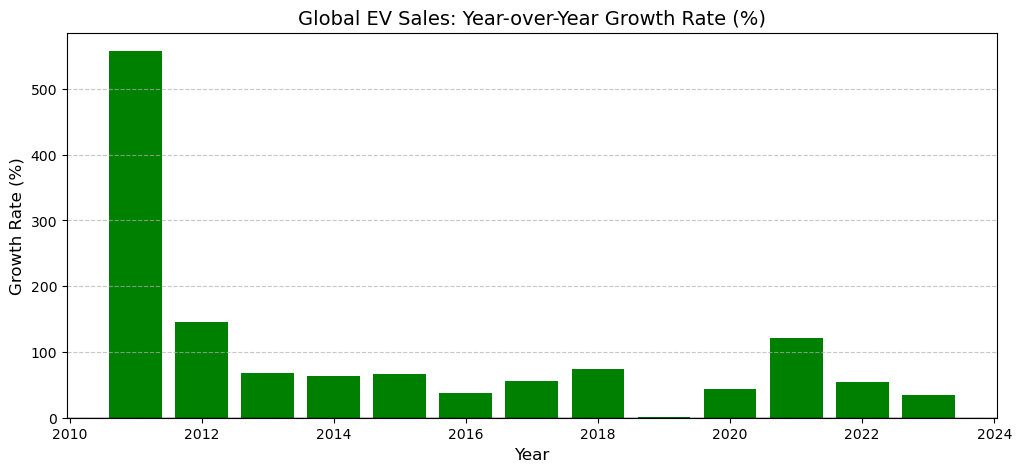

In [21]:
# 3. Plot the Growth Rate as a Bar Chart
plt.figure(figsize=(12, 5))
# Use green for positive growth, red for negative (using a simple list comprehension)
colors = ['green' if val > 0 else 'red' for val in yoy_growth.values]

plt.bar(yoy_growth.index, yoy_growth.values, color=colors)

plt.title('Global EV Sales: Year-over-Year Growth Rate (%)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1) # Adds a thick black line at 0%
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [22]:
plt.show()